# Arbitrary Geometry

In [1]:
import meep as mp
from matplotlib import pyplot as plt
import numpy as np
import time

In [2]:
cell = mp.Vector3(10, 20, 0)
pml_layers = [mp.PML(1.0)]
resolution = 30

## Define a material function

The material function is placed in the material argument for a GeometricObject (eg. Block, Cylinder, etc.). <br>
> It can also be places in the simulation object, but it doesn't work when I try and there is no any real examples for this. -> see "Test.ipynb" <br>

The material function can be any shapes, but is restricted by the range of the GeometricObject. <br>

Defining an function attribute "do_averaging" to be "True", it'll smoothing the material. <br>
> If you don't do the smoothing, you need to increase the resolution. But if you do, it will take a long time even for simple cases. -> see "donut_geom.ipynb" <br>
> Every GeometricObject is default to do the smoothing. <br>
> https://meep.readthedocs.io/en/latest/Subpixel_Smoothing/ <br>

### 1 Geometry Centers at (0,0,0)

For simplicity, our default center is (0,0,0) and setting the refractive index directly in the material function.

Problem:
- whiskers are not showing correctly (diagram and value) -> see "lines.ipynb" & "cat_geom_test.ipynb"

In [3]:
def cat_geom_1(position):

    # refractive index
    n = 1.5
    
    # eyes
    radius_min = 0.1; radius_max = 0.5
    polar_r_left = np.sqrt( (position.x-(-1))**2 + (position.y-(0))**2 )
    polar_r_right = np.sqrt( (position.x-(1))**2 + (position.y-(0))**2 )
    if radius_min <= polar_r_left <= radius_max:
        return mp.air
    if radius_min <= polar_r_right <= radius_max:
        return mp.air
    
    # mouth
    if (-0.25 <= position.x <= 0.25 and -1.5 <= position.y <= -1) and \
       (position.y <= 2*position.x-1 and position.y <= -2*position.x-1):
        return mp.air

    # whiskers
    if (2 <= position.x <= 3.5) and \
       (position.y == 0.5*position.x-2 or position.y == 0.3*position.x-2):
        return mp.Medium(index=n)
    if (-3.5 <= position.x <= -2) and \
       (position.y == -0.5*position.x-2 or position.y == -0.3*position.x-2):
        return mp.Medium(index=n)
    
    # face
    if (-3 <= position.x <= -2 and -2 <= position.y <= 4) and (position.y <= 6*position.x+16):
        return mp.Medium(index=n)
    if (2 <= position.x <= 3 and -2 <= position.y <= 4) and (position.y <= -6*position.x+16):
        return mp.Medium(index=n)
    if (-2 <= position.x <= -1 and 2 <= position.y <= 4) and (position.y <= -2*position.x):
        return mp.Medium(index=n)
    if (1 <= position.x <= 2 and 2 <= position.y <= 4) and (position.y <= 2*position.x):
        return mp.Medium(index=n)
    if (-2 <= position.x <= 2 and -2 <= position.y <= 2):
        return mp.Medium(index=n)

    # points that are not defined to any material are set to be air
    return mp.air

cat_geom_1.do_averaging = True    # subpixel smoothing

geometry_1 = []
geometry_1.append(mp.Block(center=mp.Vector3(),
                           size=cell,    # Set the GeometricObject has the same size as the cell
                           material=cat_geom_1))

     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


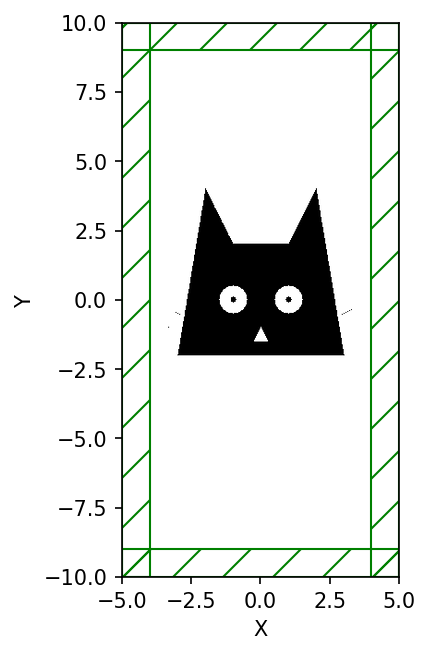

In [4]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_1,
                    resolution=resolution,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

### 2 Geometry Center at Different Places

Generally we want to set the center of the geometry and the refractive index outside the material function. <br>

But material function still can only have the position argument. So we use closure to get the center and refractive index. <br>

In this case, we set two geometry and displace their centers from (0,0,0). <br>

In [5]:
def cat_geom_2(center=mp.Vector3(), n=1.5):
    def cat_geom_2_inner(position):

        # shift the position with the center
        position -= center
        
        # eyes
        radius_min = 0.1; radius_max = 0.5
        polar_r_left = np.sqrt( (position.x-(-1))**2 + (position.y-(0))**2 )
        polar_r_right = np.sqrt( (position.x-(1))**2 + (position.y-(0))**2 )
        if radius_min <= polar_r_left <= radius_max:
            return mp.air
        if radius_min <= polar_r_right <= radius_max:
            return mp.air
        
        # nose/mouth
        if (-0.25 <= position.x <= 0.25 and -1.5 <= position.y <= -1) and \
           (position.y <= 2*position.x-1 and position.y <= -2*position.x-1):
            return mp.air
    
        # whiskers
        if (2 <= position.x <= 3.5) and \
           (position.y == 0.5*position.x-2 or position.y == 0.3*position.x-2):
            return mp.Medium(index=n)
        if (-3.5 <= position.x <= -2) and \
           (position.y == -0.5*position.x-2 or position.y == -0.3*position.x-2):
            return mp.Medium(index=n)
        
        # face
        if (-3 <= position.x <= -2 and -2 <= position.y <= 4) and (position.y <= 6*position.x+16):
            return mp.Medium(index=n)
        if (2 <= position.x <= 3 and -2 <= position.y <= 4) and (position.y <= -6*position.x+16):
            return mp.Medium(index=n)
        if (-2 <= position.x <= -1 and 2 <= position.y <= 4) and (position.y <= -2*position.x):
            return mp.Medium(index=n)
        if (1 <= position.x <= 2 and 2 <= position.y <= 4) and (position.y <= 2*position.x):
            return mp.Medium(index=n)
        if (-2 <= position.x <= 2 and -2 <= position.y <= 2):
            return mp.Medium(index=n)
        
        return mp.air
    return cat_geom_2_inner

# setting necessary arguments
center_for_block    = mp.Vector3(0,3,0)
center_for_cylinder = mp.Vector3(0,-3,0)
n_for_block         = 1.5
n_for_cylinder      = 1.5

# subpixel smoothing
cat_geom_2_block    = cat_geom_2(center_for_block, n_for_block)
cat_geom_2_cylinder = cat_geom_2(center_for_cylinder, n_for_cylinder)
cat_geom_2_block.do_averaging    = True
cat_geom_2_cylinder.do_averaging = True

geometry_2 = []
geometry_2.append(mp.Block(center=center_for_block,
                           size=cell,    # Set the GeometricObject has the same size as the cell
                           material=cat_geom_2_block))
geometry_2.append(mp.Cylinder(center=center_for_cylinder,
                              radius=2,    # Let's see what happend if we don't set the GeometricObject large enough
                              material=cat_geom_2_cylinder))

     block, center = (0,3,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,-3,0)
          radius 2, height 1e+20, axis (0, 0, 1)


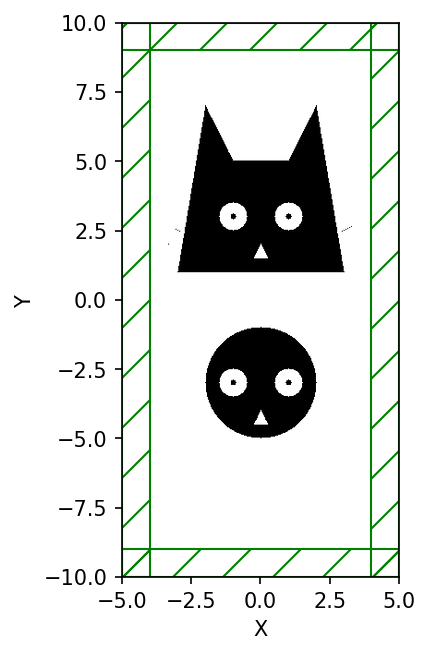

In [6]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_2,
                    resolution=resolution,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

## Add a source

In [7]:
sources = [mp.Source(mp.ContinuousSource(frequency=0.15),
                     component=mp.Ez,
                     center=mp.Vector3(0,-7),
                     size=mp.Vector3(2,0,0))]

## Simulate

Let's see if the self-defined geometry works.

### No Subpixel Smoothing

Set the function attribute "do_averaging" of the material function to be "False"

In [8]:
cat_geom_1.do_averaging = False

     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


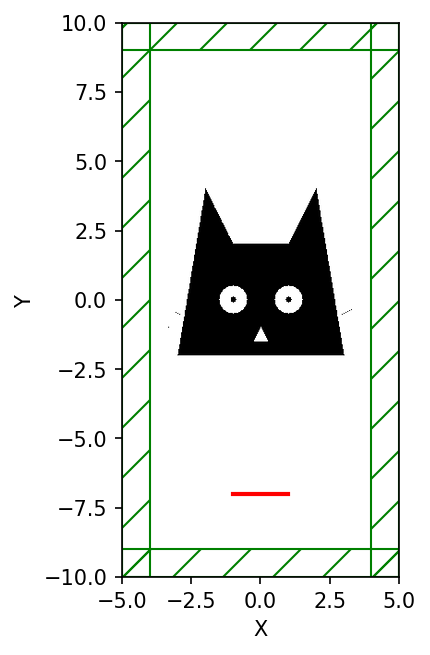

In [9]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_1,
                    resolution=resolution,
                    sources=sources,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

In [10]:
start = time.time()
sim.run(until=100)
end = time.time()

time_no_smoothing = end - start
print(f"comsumed time: {time_no_smoothing} sec")

-----------
Initializing structure...
time for choose_chunkdivision = 0.000221014 s
Working in 2D dimensions.
Computational cell is 10 x 20 x 0 with resolution 30
     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 4.9427 s
-----------


FloatProgress(value=0.0, description='0% done ')

Meep progress: 97.8/100.0 = 97.8% done in 4.0s, 0.1s to go
on time step 5871 (time=97.85), 0.000681363 s/step
run 0 finished at t = 100.0 (6000 timesteps)
comsumed time: 9.051944017410278 sec


     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


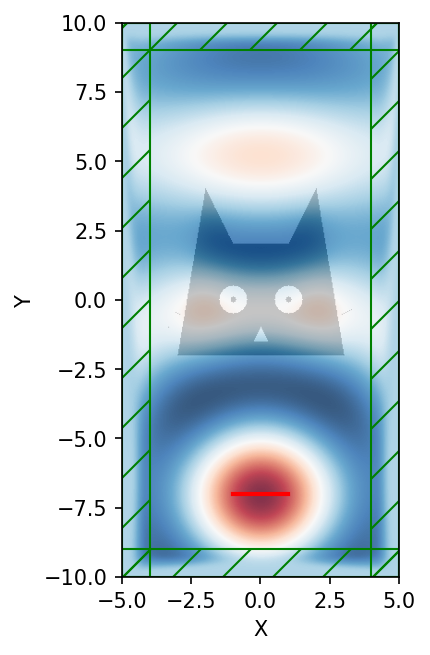

In [11]:
f = plt.figure(dpi=150)
sim.plot2D(fields=mp.Ez)
plt.show()

In [12]:
sim.reset_meep()

### Subpixel Smoothing with Default Arguments

Set the function attribute "do_averaging" of the material function to be "True" <br>

There are two arguments can be set in the Simulation class for the integration of the smoothing. In this case we use the default value, so we don't need to do anything. <br>
- subpixel_tol: float = 0.0001,-  subpixel_maxeval: int = 100000,

In [13]:
cat_geom_1.do_averaging = True

     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


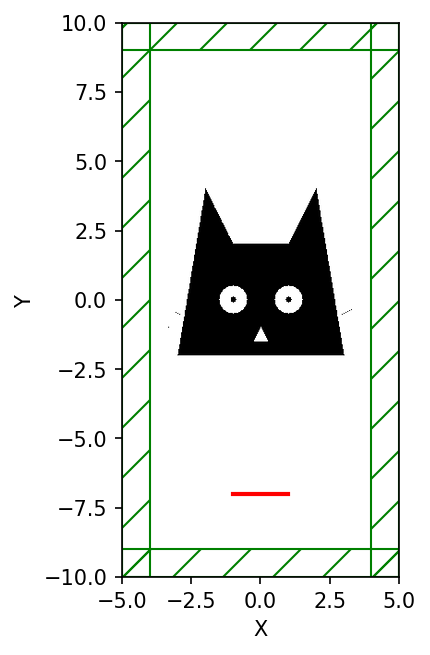

In [14]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_1,
                    resolution=resolution,
                    sources=sources,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

In [15]:
start = time.time()
sim.run(until=100)
end = time.time()

time_default_smoothing = end - start
print(f"comsumed time: {time_default_smoothing} sec")

-----------
Initializing structure...
time for choose_chunkdivision = 0.000226974 s
Working in 2D dimensions.
Computational cell is 10 x 20 x 0 with resolution 30
     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)
subpixel-averaging is 12.4196% done, 94.518 s remaining
subpixel-averaging is 13.1958% done, 230.54 s remaining
subpixel-averaging is 13.9721% done, 106.037 s remaining
subpixel-averaging is 14.7484% done, 196.747 s remaining
subpixel-averaging is 15.5246% done, 184.66 s remaining
subpixel-averaging is 16.3009% done, 174.538 s remaining
subpixel-averaging is 17.0772% done, 172.69 s remaining
subpixel-averaging is 17.8535% done, 162.076 s remaining
subpixel-averaging is 18.6297% done, 77.5305 s remaining
subpixel-averaging is 19.406% done, 146.018 s remaining
subpixel-averaging is 20.1823% done, 136.319 s remaining
subpixel-averaging is 20.9585% done, 125.283 s remaining
subpixel-averaging is 21.7348% done, 119.124 s remaining
subpix

FloatProgress(value=0.0, description='0% done ')

run 0 finished at t = 100.0 (6000 timesteps)
comsumed time: 4391.795307159424 sec


     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


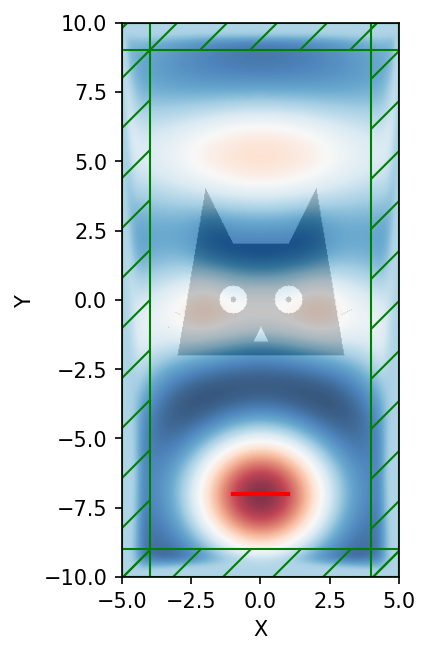

In [16]:
f = plt.figure(dpi=150)
sim.plot2D(fields=mp.Ez)
plt.show()

In [17]:
sim.reset_meep()

### Subpixel Smoothing with Self-Defined Arguments

Set the function attribute "do_averaging" of the material function to be "True" <br>

Here we set the arguments to be more tolerant so the integration time won't take so long. <br>
- subpixel_tol: float = 0.001,
- subpixel_maxeval: int = 1000,

In [18]:
cat_geom_1.do_averaging = True

     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


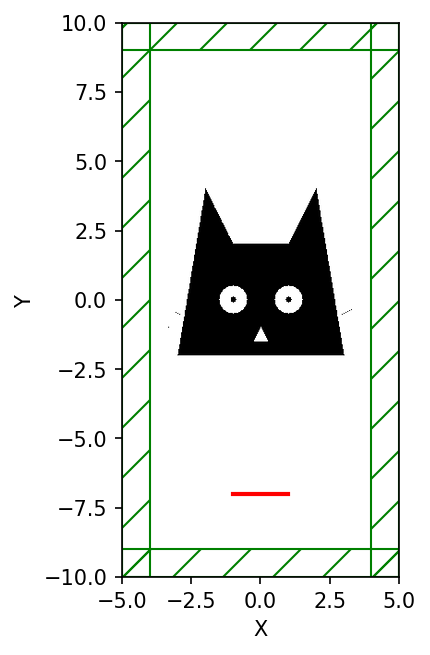

In [19]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_1,
                    resolution=resolution,
                    subpixel_tol=0.001,
                    subpixel_maxeval=1000,
                    sources=sources,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

In [20]:
start = time.time()
sim.run(until=100)
end = time.time()

time_modified_smoothing = end - start
print(f"comsumed time: {time_modified_smoothing} sec")

-----------
Initializing structure...
time for choose_chunkdivision = 0.000257015 s
Working in 2D dimensions.
Computational cell is 10 x 20 x 0 with resolution 30
     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)
subpixel-averaging is 18.6297% done, 18.3472 s remaining
subpixel-averaging is 26.3924% done, 11.8505 s remaining
subpixel-averaging is 35.7077% done, 7.21355 s remaining
subpixel-averaging is 48.9043% done, 4.41735 s remaining
subpixel-averaging is 63.6534% done, 2.50486 s remaining
subpixel-averaging is 72.9687% done, 1.54965 s remaining
subpixel-averaging is 80.7314% done, 0.975037 s remaining
subpixel-averaging is 90.0467% done, 0.443125 s remaining
subpixel-averaging is 19.406% done, 18.0739 s remaining
subpixel-averaging is 28.7212% done, 10.1837 s remaining
subpixel-averaging is 38.0365% done, 6.85732 s remaining
subpixel-averaging is 55.1145% done, 3.29855 s remaining
subpixel-averaging is 66.7585% done, 2.08362 s remaining


FloatProgress(value=0.0, description='0% done ')

run 0 finished at t = 100.0 (6000 timesteps)
comsumed time: 108.96595811843872 sec


     block, center = (0,0,0)
          size (10,20,0)
          axes (1,0,0), (0,1,0), (0,0,1)


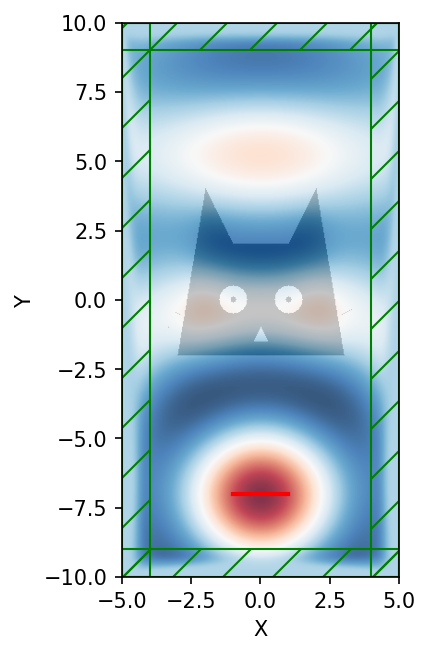

In [21]:
f = plt.figure(dpi=150)
sim.plot2D(fields=mp.Ez)
plt.show()

### Comsuming Time Comparison

In [22]:
print(f"no smoothing: {time_no_smoothing: .2f} sec")
print(f"smoothing with default arguments: {time_default_smoothing: .2f} sec")
print(f"smoothing with modified arguments: {time_modified_smoothing: .2f} sec")

no smoothing:  9.05 sec
smoothing with default arguments:  4391.80 sec
smoothing with modified arguments:  108.97 sec
